In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cooltools
from scipy.optimize import fsolve
from numpy import nanmean
import pandas as pd
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import cooler
from coolpuppy import coolpup

%matplotlib inline



In [10]:
# chipdata="/Users/dariodasaro/Desktop/PhD_data/ENS/mcpoly_data/GSE151416_RAW"+"/GSM4577764_Mcd1p_WT.bigwig"
chipdata="/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/mono.midpoint.bigwig"


chroms = ['chrI',
 'chrII',
 'chrIII',
 'chrIV',
 'chrV',
 'chrVI',
 'chrVII',
 'chrVIII',
 'chrIX',
 'chrX',
 'chrXI',
 'chrXII',
 'chrXIII',
 'chrXIV',
 'chrXV',
 'chrXVI']


(200000.0, 255000.0)

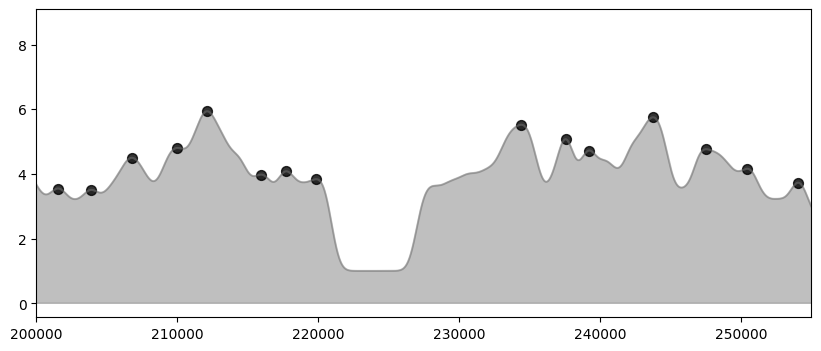

In [ ]:
## example loading a bigwig file and plotting the data for a specific chromosome
plt.figure(figsize=(10, 4))
#load dataframe from bigwig file for chromosome chosen
chrom = 'chrII'
df1 = bioframe.read_bigwig(chipdata, chrom)

#note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')

enrichment_uniform = f(pos_uniform)

# Smooth 
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=500)

plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)



#find peaks in the data using scipy find_peaks function, with a minimum height of min_h and a minimum distance of min_d between peaks.
min_h=2
min_d=10
prominence=0.020
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)


xlims = [200_000, 255_000]
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)


In [6]:
#create a dataframe with the peaks heights and positions

CARs_df = []
for chrom in chroms[:]:
    df1 = bioframe.read_bigwig(chipdata, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=1000)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    CARs_df.append(chrom_df)
CARs_df = pd.concat(CARs_df, ignore_index=True)


In [ ]:
## create df for cooltools off-diagonal plots using only NN CARS

CARs_df_NN=[]

for chrom in chroms[:]:
    CARs_df_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])


    chrom_mask = CARs_df["chrom"]==chrom
   
    #you may want to add a filter for the CAR strength, for example only consider CARs with strength above a certain threshold
    #strength_mask = CARs_df[chrom_mask]["CAR strength"] > 2

    CARs_df_NN_chrom["chrom1"]=list(CARs_df[chrom_mask][:-1]["chrom"])
    CARs_df_NN_chrom["chrom2"]=list(CARs_df[chrom_mask][1:]["chrom"])

    CARs_df_NN_chrom["start1"]=list(CARs_df[chrom_mask][:-1]["start"])
    CARs_df_NN_chrom["start2"]=list(CARs_df[chrom_mask][1:]["start"]) 

    CARs_df_NN_chrom["end1"]=list(CARs_df[chrom_mask][:-1]["end"])
    CARs_df_NN_chrom["end2"]=list(CARs_df[chrom_mask][1:]["end"])

    CARs_df_NN_chrom["CAR strength1"]=list(CARs_df[chrom_mask][:-1]["CAR strength"])
    CARs_df_NN_chrom["CAR strength2"]=list(CARs_df[chrom_mask][1:]["CAR strength"])

    CARs_df_NN.append(CARs_df_NN_chrom)

CARs_df_NN = pd.concat(CARs_df_NN, ignore_index=True)

In [ ]:
# CARs_df_NN

df_zone = CARs_df_NN[
    (
        (CARs_df_NN["chrom1"] == chrom) &
        (CARs_df_NN["start1"].between(*xlims))
    )
    |
    (
        (CARs_df_NN["chrom2"] == chrom) &
        (CARs_df_NN["start2"].between(*xlims))
    )
]

print(df_zone)

      chrom1    start1      end1  CAR strength1  chrom2    start2      end2  \
1600  chrXVI  199595.0  199595.0       3.782246  chrXVI  206473.0  206473.0   
1601  chrXVI  206473.0  206473.0       3.752996  chrXVI  210536.0  210536.0   
1602  chrXVI  210536.0  210536.0       3.760148  chrXVI  219846.0  219846.0   
1603  chrXVI  219846.0  219846.0       4.121672  chrXVI  224248.0  224248.0   
1604  chrXVI  224248.0  224248.0       4.206069  chrXVI  233100.0  233100.0   
1605  chrXVI  233100.0  233100.0       4.561677  chrXVI  251040.0  251040.0   
1606  chrXVI  251040.0  251040.0       4.231366  chrXVI  262302.0  262302.0   

      CAR strength2  
1600       3.752996  
1601       3.760148  
1602       4.121672  
1603       4.206069  
1604       4.561677  
1605       4.231366  
1606       3.879328  


In [16]:
# #Load cooler file and create expected dataframe for the off-diagonal plots

# resolution=1000
# clr = cooler.Cooler("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/AD908_G2_mixed.mcool::/resolutions/" + str(resolution))
# view_df=pd.DataFrame({"chrom":clr.chromnames,"start":0,"end":clr.chromsizes.values,"name":clr.chromnames})

# #compute expected cis using cooltools (a df containing the P(s))
# cvd = cooltools.expected_cis(
# clr=clr,
#     view_df=view_df,
#     clr_weight_name=None,
#     smooth=True,
#     aggregate_smoothed=False,
#     nproc=8 #if you do not have multiple cores available, set to 1
#     )



# flank= 5_000 #window size NB this is also the minimal distance between CARs that will be considered. If you consider too many low strength CARs that may be a problem

# # create the stack of snips:
# pup = coolpup.pileup(
#     clr,
#     CARs_df_NN,
#     features_format='bedpe',
#     flank=flank,
#     view_df=view_df,
#     expected_df=cvd,
#     clr_weight_name="weight",
#     nproc=8
# )

In [17]:
# fig, ax = plt.subplots(figsize=(6, 6))
# mtx=pup.loc[0, 'data']
# im=ax.imshow(
#     np.log2((mtx)),
#     cmap='bwr',
#     vmin=-2,
#     vmax=2,
# interpolation='none')

# ticks_pixels = np.linspace(0, flank*2//resolution,9)
# ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
# ax.set(
#     xticks=ticks_pixels,
#     xticklabels=ticks_kbp,
#     yticks=ticks_pixels,
#     yticklabels=ticks_kbp,
#     xlabel='relative position, kbp'
#     )
        
# fig.tight_layout()



# .